# Sampel 3, Motif Kotak

In [139]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [140]:
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import skan
from utils import *

In [141]:
square_center = cv2.imread('sampel-3_motif-kotak-tengah.png')
square_center_binary = binarize(square_center)
square_corner = cv2.imread('sampel-3_motif-kotak-sudut.png')
square_corner_binary = binarize(square_corner)

## Titik Tengah

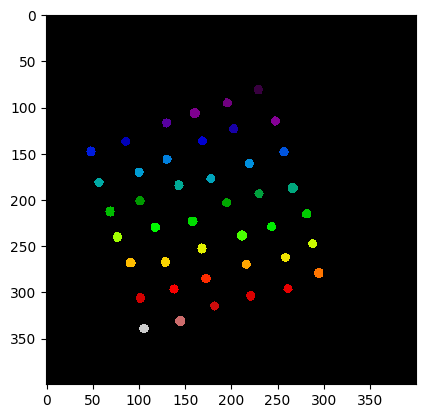

In [142]:
num_center, center_map, center_stats, center_centroids = cv2.connectedComponentsWithStats(square_center_binary)

plt.imshow(center_map[1600:2000, 800:1200], cmap='nipy_spectral', interpolation='nearest')

array([[8.97145449e-02, 0.00000000e+00],
       [9.33710879e-02, 1.00000000e+00],
       [9.69991891e-02, 2.00000000e+00],
       ...,
       [9.72664588e-02, 1.77000000e+02],
       [1.00872302e-01, 1.78000000e+02],
       [1.04447418e-01, 1.79000000e+02]])

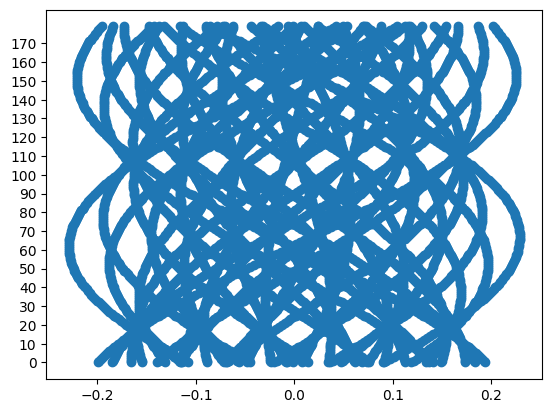

In [198]:
center_standardized = standardizeContour(center_centroids[1:])

center_parallel_test = testParallel(center_standardized, 180)

plt.scatter(center_parallel_test[:, 0], center_parallel_test[:, 1])
plt.yticks(range(0, 180, 10))

center_parallel_test

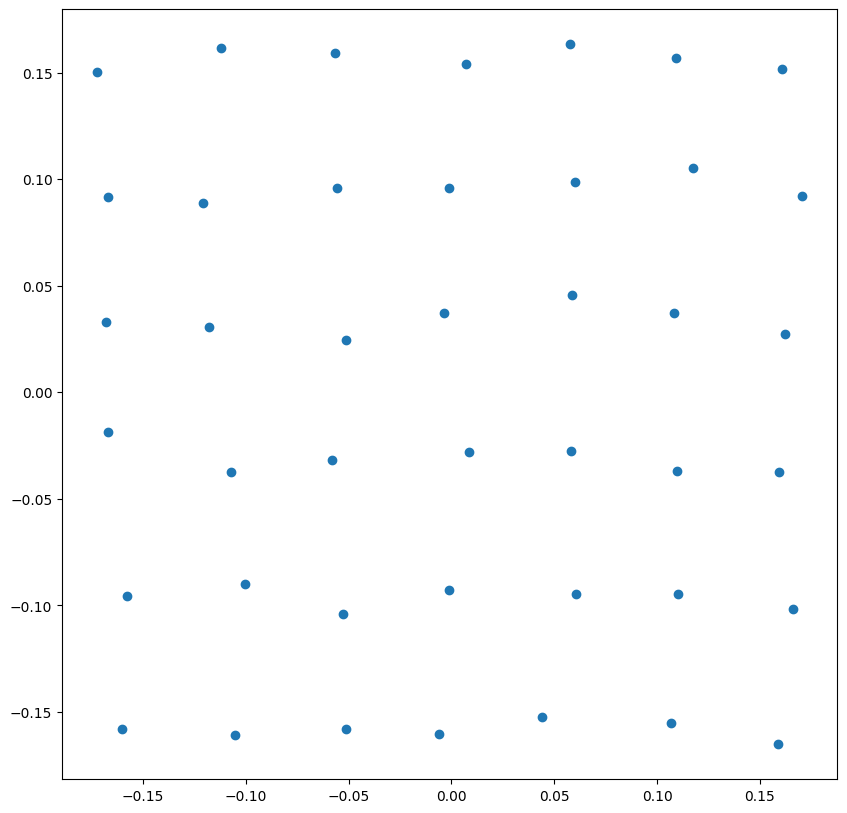

In [179]:
center_rotated = rotateToAngle(center_standardized, 18)

plt.figure(figsize=(10, 10))
plt.scatter(center_rotated[:, 0], center_rotated[:, 1])

In [197]:
x_parallel_borders = [[-0.2, -0.14], [-0.13, -0.07], [-0.06, 0.0], [0, 0.06], [0.07, 0.13], [0.13, 0.2]]

x_distances = []
for left, right in x_parallel_borders:
    coordinate_parallels = center_rotated[(center_rotated[:, 1] >= left) & (center_rotated[:, 1] <= right)]
    current_distances = []
    for i in range(len(coordinate_parallels) - 1):
        for j in range(i + 1, len(coordinate_parallels)):
            current_distances.append(abs(coordinate_parallels[i, 0] - coordinate_parallels[j, 0]))
    current_distances.sort()
    current_distances = current_distances[:len(coordinate_parallels) - 1]
    x_distances = x_distances + current_distances

summarizeData(x_distances, "Horizontal Distances")

DATA SUMMARY of [Horizontal Distances]:
Num     : 36
Mean    : 0.0547
SD      : 0.0059
SD rel  : 10.86%
Median  : 0.0534
MAD     : 0.0039
MAD rel : 7.32%
Min     : 0.0455
Max     : 0.0666



{'num': 36,
 'mean': 0.05473065101046781,
 'sd': 0.005942973807741491,
 'median': 0.05342007969335434,
 'mad': 0.003908788876755321,
 'min': 0.04547176298327319,
 'max': 0.06664080046390138}

In [196]:
y_parallel_borders = [[-0.2, -0.15], [-0.13, -0.08], [-0.08, -0.03], [-0.03, 0.04], [0.09, 0.13], [0.13, 0.2]]

y_distances = []
for left, right in y_parallel_borders:
    coordinate_parallels = center_rotated[(center_rotated[:, 0] >= left) & (center_rotated[:, 0] <= right)]
    current_distances = []
    for i in range(len(coordinate_parallels) - 1):
        for j in range(i + 1, len(coordinate_parallels)):
            current_distances.append(abs(coordinate_parallels[i, 1] - coordinate_parallels[j, 1]))
    current_distances.sort()
    current_distances = current_distances[:len(coordinate_parallels) - 1]
    y_distances = y_distances + current_distances

summarizeData(y_distances, "Vertical Distances")

DATA SUMMARY of [Vertical Distances]:
Num     : 30
Mean    : 0.0630
SD      : 0.0067
SD rel  : 10.59%
Median  : 0.0635
MAD     : 0.0049
MAD rel : 7.71%
Min     : 0.0517
Max     : 0.0767



{'num': 30,
 'mean': 0.06302515573791101,
 'sd': 0.006675838877210201,
 'median': 0.06347111857887432,
 'mad': 0.004891976651720056,
 'min': 0.05166576142877717,
 'max': 0.07667083067887936}

## Titik Sudut

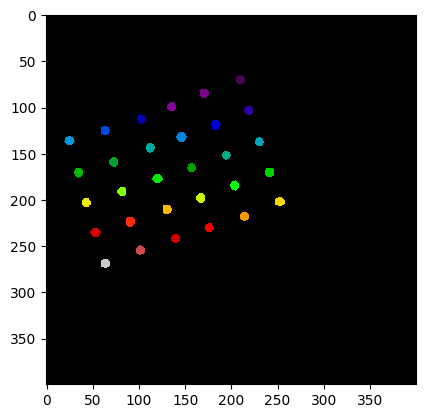

In [199]:
num_corner, corner_map, corner_stats, corner_centroids = cv2.connectedComponentsWithStats(square_corner_binary)

plt.imshow(corner_map[1600:2000, 800:1200], cmap='nipy_spectral', interpolation='nearest')

array([[1.57537857e-01, 0.00000000e+00],
       [1.61374323e-01, 1.00000000e+00],
       [1.65161634e-01, 2.00000000e+00],
       ...,
       [1.51334459e-01, 1.77000000e+02],
       [1.55224835e-01, 1.78000000e+02],
       [1.59067929e-01, 1.79000000e+02]])

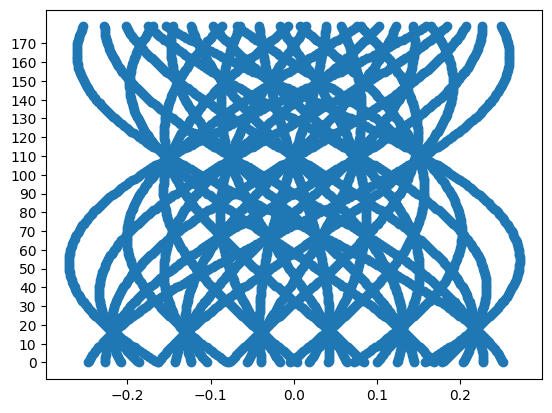

In [200]:
corner_standardized = standardizeContour(corner_centroids[1:])

corner_parallel_test = testParallel(corner_standardized, 180)

plt.scatter(corner_parallel_test[:, 0], corner_parallel_test[:, 1])
plt.yticks(range(0, 180, 10))

corner_parallel_test

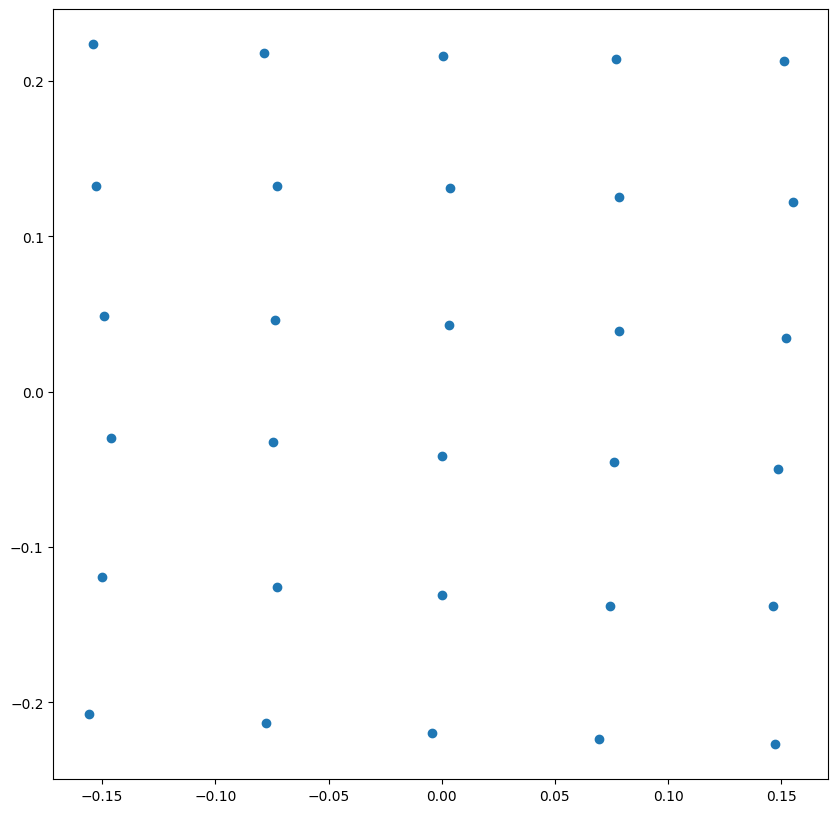

In [205]:
corner_rotated = rotateToAngle(corner_standardized, 20)

plt.figure(figsize=(10, 10))
plt.scatter(corner_rotated[:, 0], corner_rotated[:, 1])

In [210]:
x_parallel_borders = [[-0.25, -0.19], [-0.17, -0.1], [-0.1, 0.0], [0, 0.1], [0.1, 0.18], [0.18, 0.25]]

x_distances = []
for left, right in x_parallel_borders:
    coordinate_parallels = corner_rotated[(corner_rotated[:, 1] >= left) & (corner_rotated[:, 1] <= right)]
    current_distances = []
    for i in range(len(coordinate_parallels) - 1):
        for j in range(i + 1, len(coordinate_parallels)):
            current_distances.append(abs(coordinate_parallels[i, 0] - coordinate_parallels[j, 0]))
    current_distances.sort()
    current_distances = current_distances[:len(coordinate_parallels) - 1]
    x_distances = x_distances + current_distances

summarizeData(x_distances, "Horizontal Distances")

DATA SUMMARY of [Horizontal Distances]:
Num     : 24
Mean    : 0.0754
SD      : 0.0022
SD rel  : 2.92%
Median  : 0.0754
MAD     : 0.0016
MAD rel : 2.15%
Min     : 0.0716
Max     : 0.0799



{'num': 24,
 'mean': 0.07535031254187959,
 'sd': 0.0022008685265806865,
 'median': 0.0754481778951251,
 'mad': 0.0016232871823005646,
 'min': 0.07158944513857599,
 'max': 0.07993435378273511}

In [212]:
y_parallel_borders = [[-0.2, -0.1], [-0.1, -0.05], [-0.04, 0.03], [0.05, 0.11], [0.11, 0.2]]

y_distances = []
for left, right in y_parallel_borders:
    coordinate_parallels = corner_rotated[(corner_rotated[:, 0] >= left) & (corner_rotated[:, 0] <= right)]
    current_distances = []
    for i in range(len(coordinate_parallels) - 1):
        for j in range(i + 1, len(coordinate_parallels)):
            current_distances.append(abs(coordinate_parallels[i, 1] - coordinate_parallels[j, 1]))
    current_distances.sort()
    current_distances = current_distances[:len(coordinate_parallels) - 1]
    y_distances = y_distances + current_distances

summarizeData(y_distances, "Vertical Distances")

DATA SUMMARY of [Vertical Distances]:
Num     : 25
Mean    : 0.0870
SD      : 0.0035
SD rel  : 4.00%
Median  : 0.0875
MAD     : 0.0019
MAD rel : 2.23%
Min     : 0.0785
Max     : 0.0931



{'num': 25,
 'mean': 0.08703227885123929,
 'sd': 0.0034810545341160603,
 'median': 0.08752968286058108,
 'mad': 0.0019487618662298034,
 'min': 0.07853513206822575,
 'max': 0.09314688207707106}